# Stage 2: Cross-State Difference-in-Differences (CA vs AZ)

**Project:** Does Daylight Saving Time Reduce Property Crime?  
**Course:** IDS 701 — Problem Solving with Data Science, Duke University, Spring 2026  
**Design:** California (treated, observes DST) vs Arizona (control, never observes DST)  
**Outcomes:** Burglary and Motor Vehicle Theft (daily county-level rates per 100k residents)  
**Period:** 2022–2024  

**AZ control group:** Apache, Navajo, and Coconino (Navajo Nation) are excluded as they observe DST and would contaminate the control group. Data artifacts (MARICOPA, PINAL multi-county entry and NOT SPECIFIED) are also excluded.

---

### Notebook structure

| Section | Content |
|---|---|
| 0 | Setup |
| 1 | Build model panel |
| 1.2 | Day-of-week patterns |
| 1.3 | Monthly seasonality |
| 2 | Parallel trends check |
| 3 | Main TWFE DiD |
| 3.2 | Hourly mechanism test |
| 4 | Narrow-window check |
| 5 | Event study |
| 6 | Robustness checks |
| 7 | Summary |

## Section 0 — Setup

In [63]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm

# ── Find project root ──────────────────────────────────────────────────────
_root = Path.cwd()
for _ in range(4):
    if (_root / "data").exists() and (_root / "scripts").exists():
        break
    _root = _root.parent
os.chdir(_root)

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

# ── File paths ─────────────────────────────────────────────────────────────
CRIME_PATH    = Path("data/processed/crime/focus_states_daily_county_counts.csv")
POP_PATH      = Path("data/processed/population/focus_states_county_population_2020_2024_long.csv")
ACS_PATH      = Path("data/processed/analysis/acs_distributions_2023.csv")
COVERAGE_PATH = Path("data/processed/analysis/agency_coverage.csv")
PT_PATH       = Path("data/processed/analysis/parallel_trends_monthly.csv")
HOURLY_PATH   = Path("data/processed/analysis/hourly_by_dst_period_year.csv")
DOW_PATH        = Path("data/processed/analysis/dow_pattern_by_year.csv")
SEAS_PATH       = Path("data/processed/analysis/monthly_seasonality_by_year.csv")
TRANSITION_PATH = Path("data/processed/analysis/dst_transition_window.csv")
SHARE_PATH      = Path("data/processed/analysis/evening_morning_share.csv")

# ── Constants ──────────────────────────────────────────────────────────────
STATES       = ["CA", "AZ"]
CRIMES       = ["burglary", "motor_vehicle_theft"]
CRIME_LABELS = {"burglary": "Burglary", "motor_vehicle_theft": "Motor Vehicle Theft"}
STATE_COLORS = {"CA": "blue", "AZ": "pink"}
AZ_EXCLUDE   = {"APACHE", "NAVAJO", "COCONINO"}

# ── DST transition dates ───────────────────────────────────────────────────
def spring_forward(year):
    d0 = date(year, 3, 1)
    return d0 + timedelta(days=(6 - d0.weekday()) % 7) + timedelta(days=7)

def fall_back(year):
    d0 = date(year, 11, 1)
    return d0 + timedelta(days=(6 - d0.weekday()) % 7)

DST_DATES = {
    y: {"start": spring_forward(y), "end": fall_back(y)}
    for y in [2022, 2023, 2024]
}

print("Working dir:", Path.cwd())
print("\nDST transition dates:")
for y, d in DST_DATES.items():
    print(f"  {y}: spring-forward={d['start']}  fall-back={d['end']}")
print("\nFile availability:")
for p in [CRIME_PATH, POP_PATH, ACS_PATH, COVERAGE_PATH, PT_PATH,
          HOURLY_PATH, DOW_PATH, SEAS_PATH, TRANSITION_PATH, SHARE_PATH]:
    print(f"  {p.name}: {'OK' if p.exists() else 'MISSING'}")

Working dir: /Users/shellyy/Desktop/IDS_701/IDS701_UDS_Final_Project

DST transition dates:
  2022: spring-forward=2022-03-13  fall-back=2022-11-06
  2023: spring-forward=2023-03-12  fall-back=2023-11-05
  2024: spring-forward=2024-03-10  fall-back=2024-11-03

File availability:
  focus_states_daily_county_counts.csv: OK
  focus_states_county_population_2020_2024_long.csv: OK
  acs_distributions_2023.csv: OK
  agency_coverage.csv: OK
  parallel_trends_monthly.csv: OK
  hourly_by_dst_period_year.csv: OK
  dow_pattern_by_year.csv: OK
  monthly_seasonality_by_year.csv: OK
  dst_transition_window.csv: OK
  evening_morning_share.csv: OK


## Section 1 — Build Model Panel

Builds the county-day panel from raw crime counts, population, and ACS socioeconomic controls.

**Steps:**
1. Load and filter crime data to CA/AZ, target crimes, 2022–2024
2. Build population and ACS lookups
3. Remove data artifacts using agency coverage file
4. Add time features and DST treatment indicator
5. Merge population and ACS, compute crime rates

**Treatment variable:** `in_dst_window` = 1 for CA counties during the DST calendar window (spring-forward through fall-back), 0 for AZ counties year-round.

**Outcome:** `crime_rate_per_100k` = daily incidents / county population × 100,000.

In [64]:
# ── Load and filter crime data ─────────────────────────────────────────
crime = pd.read_csv(CRIME_PATH, parse_dates=["incident_date"])

crime = crime[
    crime["state"].isin(STATES) &
    crime["crime_type"].isin(CRIMES) &
    crime["incident_date"].dt.year.between(2022, 2024)
].copy()

crime["county_name"] = crime["county_name"].str.upper().str.strip()

# Exclude Navajo Nation AZ counties
crime = crime[~(
    (crime["state"] == "AZ") & (crime["county_name"].isin(AZ_EXCLUDE))
)].copy()

print(f"Crime rows after initial filter: {len(crime):,}")
print(f"States: {sorted(crime['state'].unique())}")
print(f"Years:  {sorted(crime['incident_date'].dt.year.unique())}")
print(f"Counties per state:")
print(crime.groupby('state')['county_name'].nunique())

Crime rows after initial filter: 80,559
States: ['AZ', 'CA']
Years:  [np.int32(2022), np.int32(2023), np.int32(2024)]
Counties per state:
state
AZ    13
CA    59
Name: county_name, dtype: int64


In [65]:
# ── Build population and ACS lookups ───────────────────────────────────

# Population lookup (state × county × year)
pop = pd.read_csv(POP_PATH)
pop["data_year"]   = pop["data_year"].astype(int)
pop["county_name"] = pop["county_name"].str.upper().str.strip()
pop["population"]  = pd.to_numeric(pop["population"], errors="coerce")
pop = pop[
    pop["state"].isin(STATES) &
    ~((pop["state"] == "AZ") & (pop["county_name"].isin(AZ_EXCLUDE)))
].copy()
pop_lookup = pop[["state", "county_name", "data_year", "population"]]

# ACS lookup — 2023 cross-section from analysis folder
# Socioeconomic characteristics change slowly so one year is sufficient
acs = pd.read_csv(ACS_PATH)
acs["county_name"] = (
    acs["county_name"].str.upper().str.strip()
    .str.replace(" COUNTY", "", regex=False)
)
acs = acs[acs["state"].isin(STATES)].copy()
for col in ["median_household_income", "poverty_rate",
            "unemployment_rate", "bachelors_plus_rate"]:
    if col in acs.columns:
        acs[col] = pd.to_numeric(acs[col], errors="coerce")
acs_lookup = acs[["state", "county_name", "median_household_income",
                  "poverty_rate", "unemployment_rate", "bachelors_plus_rate"]]

print("Population lookup shape:", pop_lookup.shape)
print("ACS lookup shape:",        acs_lookup.shape)
print("\nACS sample:")
print(acs_lookup.head(3))

Population lookup shape: (350, 4)
ACS lookup shape: (73, 6)

ACS sample:
  state county_name  median_household_income  poverty_rate  unemployment_rate  \
0    AZ      APACHE              40338.00000       0.31224            0.09106   
1    AZ     COCHISE              58970.00000       0.15539            0.06801   
2    AZ    COCONINO              69748.00000       0.17683            0.06217   

   bachelors_plus_rate  
0              0.15269  
1              0.27658  
2              0.39619  


In [66]:
# ── Agency coverage note ───────────────────────────────────────────────
# Retaining all counties except Navajo Nation

coverage = pd.read_csv(COVERAGE_PATH)
coverage["county_name"] = coverage["county_name"].str.upper().str.strip()

# Drop data artifacts only — not real counties
ARTIFACTS = {"MARICOPA, PINAL", "NOT SPECIFIED"}

crime = crime[~crime["county_name"].isin(ARTIFACTS)].copy()

print(f"Counties per state after artifact removal:")
print(crime.groupby("state")["county_name"].nunique())
print(f"Crime rows: {len(crime):,}")
print(f"\nAZ counties retained:")
print(sorted(crime[crime["state"] == "AZ"]["county_name"].unique()))

Counties per state after artifact removal:
state
AZ    11
CA    58
Name: county_name, dtype: int64
Crime rows: 79,486

AZ counties retained:
['COCHISE', 'GILA', 'GREENLEE', 'LA PAZ', 'MARICOPA', 'MOHAVE', 'PIMA', 'PINAL', 'SANTA CRUZ', 'YAVAPAI', 'YUMA']


In [67]:
# ── Add time features and DST treatment indicator ──────────────────────
crime["year"]        = crime["incident_date"].dt.year
crime["month"]       = crime["incident_date"].dt.month
crime["day_of_week"] = crime["incident_date"].dt.dayofweek
crime["is_weekend"]  = crime["day_of_week"].isin([5, 6]).astype(int)
crime["year_month"]  = crime["incident_date"].dt.to_period("M").astype(str)

HOLIDAYS = {
    pd.Timestamp(d)
    for y in [2022, 2023, 2024]
    for d in [f"{y}-01-01", f"{y}-07-04",
              f"{y}-11-11", f"{y}-12-25", f"{y}-12-31"]
}
crime["is_holiday"] = crime["incident_date"].isin(HOLIDAYS).astype(int)

# DST treatment: 1 for CA during DST window, always 0 for AZ
def in_dst(row):
    if row["state"] == "AZ":
        return 0
    d = row["incident_date"].date()
    y = row["year"]
    return int(DST_DATES[y]["start"] <= d < DST_DATES[y]["end"])

crime["in_dst_window"] = crime.apply(in_dst, axis=1)

# Days relative to spring-forward (used in event study and narrow window)
def days_from_spring(row):
    return (row["incident_date"].date() - DST_DATES[row["year"]]["start"]).days

crime["days_from_dst_start"] = crime.apply(days_from_spring, axis=1)

print("DST window coverage (should be ~0.67 for CA, 0.0 for AZ):")
print(crime.groupby(["state", "year"])["in_dst_window"].mean().round(3))

DST window coverage (should be ~0.67 for CA, 0.0 for AZ):
state  year
AZ     2022   0.00000
       2023   0.00000
       2024   0.00000
CA     2022   0.66500
       2023   0.65400
       2024   0.64900
Name: in_dst_window, dtype: float64


In [68]:
# ── Merge population and ACS, compute crime rates ──────────────────────

# Merge population (state × county × year)
panel = crime.merge(
    pop_lookup,
    left_on=["state", "county_name", "year"],
    right_on=["state", "county_name", "data_year"],
    how="left"
)

# Merge ACS (cross-section — state × county only, no year)
panel = panel.merge(
    acs_lookup,
    on=["state", "county_name"],
    how="left"
)

# Compute crime rate
panel["crime_rate_per_100k"] = (
    panel["incident_count"] / panel["population"] * 100_000
)
panel["log_rate"] = np.log1p(panel["crime_rate_per_100k"])

missing_pop = panel["population"].isna().sum()
panel = panel.dropna(subset=["population"]).copy()

print(f"Panel shape: {panel.shape}")
print(f"Rows dropped (missing population): {missing_pop}")
print(f"\nCounties per state:")
print(panel.groupby("state")["county_name"].nunique())
print(f"\nMissing values:")
print(panel[["crime_rate_per_100k", "median_household_income", "poverty_rate"]].isna().sum())

Panel shape: (79486, 21)
Rows dropped (missing population): 0

Counties per state:
state
AZ    11
CA    58
Name: county_name, dtype: int64

Missing values:
crime_rate_per_100k        0
median_household_income    0
poverty_rate               0
dtype: int64


## Section 1.2 Day-of-Week Crime Patterns

Before running the regression, we verify that day-of-week genuinely affects 
crime rates in both states — justifying the inclusion of `is_weekend` as a 
control variable in all specifications.

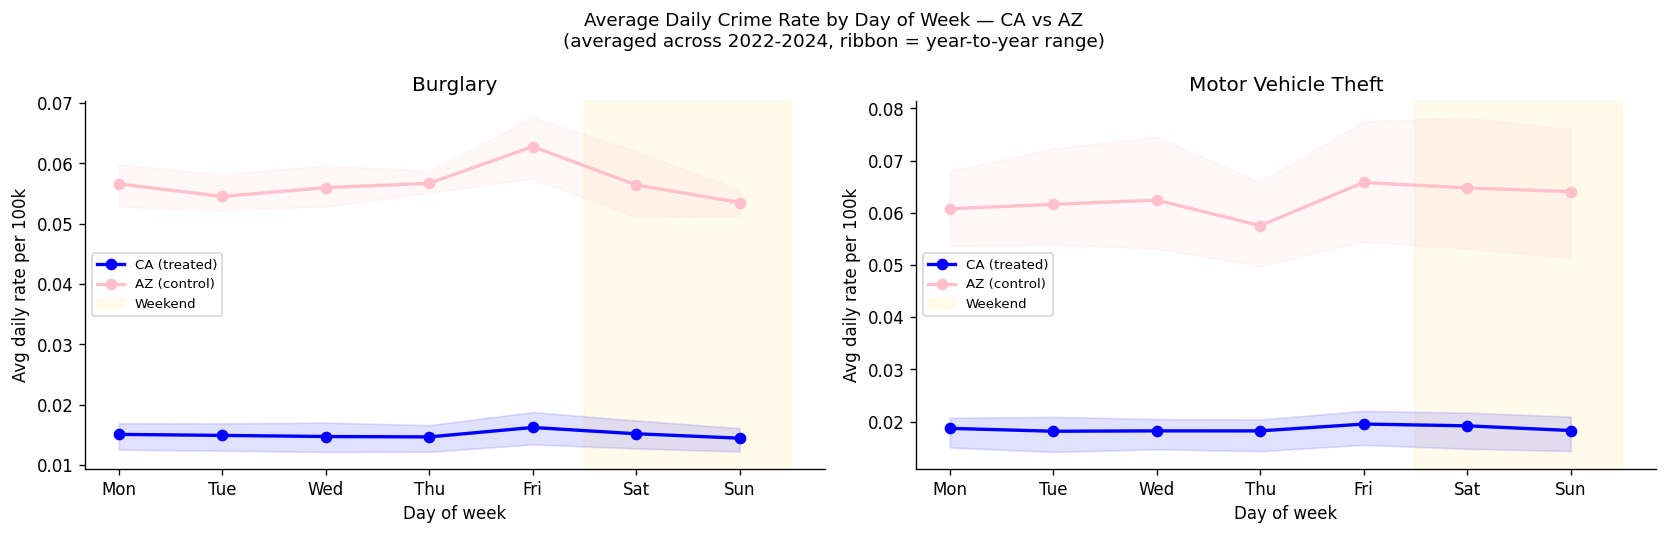


Weekend vs weekday average — CA:
  Burglary: weekday=0.0151  weekend=0.0148  diff=-0.0003
  Motor Vehicle Theft: weekday=0.0186  weekend=0.0187  diff=+0.0002


In [69]:
# ── Day-of-week crime patterns ─────────────────────────────────────────────

DOW_PATH = Path("data/processed/analysis/dow_pattern_by_year.csv")
dow = pd.read_csv(DOW_PATH)
dow = dow[
    dow["state"].isin(["CA", "AZ"]) &
    dow["crime_type"].isin(CRIMES)
].copy()

# Collapse across years
dow_avg = (
    dow.groupby(["state", "day_of_week", "crime_type"], as_index=False)
    .agg(
        avg_rate=("avg_daily_rate_per_100k", "mean"),
        lo_rate=("avg_daily_rate_per_100k", "min"),
        hi_rate=("avg_daily_rate_per_100k", "max"),
    )
)

DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(
    "Average Daily Crime Rate by Day of Week — CA vs AZ\n"
    "(averaged across 2022-2024, ribbon = year-to-year range)",
    fontsize=11
)

for ax, ct in zip(axes, CRIMES):
    sub = dow_avg[dow_avg["crime_type"] == ct]

    for state in ["CA", "AZ"]:
        s = sub[sub["state"] == state].sort_values("day_of_week")
        ax.plot(
            s["day_of_week"], s["avg_rate"],
            color=STATE_COLORS[state], lw=2, marker="o", ms=6,
            label=f"{state} ({'treated' if state == 'CA' else 'control'})"
        )
        ax.fill_between(
            s["day_of_week"], s["lo_rate"], s["hi_rate"],
            color=STATE_COLORS[state], alpha=0.12
        )

    # Shade weekend
    ax.axvspan(4.5, 6.5, alpha=0.08, color="gold", zorder=0, label="Weekend")
    ax.set_xticks(range(7))
    ax.set_xticklabels(DAY_LABELS)
    ax.set_title(CRIME_LABELS[ct])
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Avg daily rate per 100k")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nWeekend vs weekday average — CA:")
for ct in CRIMES:
    sub = dow[dow["state"] == "CA"][dow["crime_type"] == ct]
    wknd = sub[sub["day_of_week"].isin([5, 6])]["avg_daily_rate_per_100k"].mean()
    wkdy = sub[sub["day_of_week"].isin(range(5))]["avg_daily_rate_per_100k"].mean()
    print(f"  {CRIME_LABELS[ct]}: weekday={wkdy:.4f}  weekend={wknd:.4f}  diff={wknd-wkdy:+.4f}")

## Section 1.3 Monthly Seasonality — The Confounding Problem

Before the parallel trends check, we first show why a simple within-state 
comparison of DST vs standard time months is insufficient. Monthly crime 
rates follow a strong seasonal pattern in both CA and AZ — crime peaks in 
summer and falls in winter, independent of DST. Since DST months (March–
October) coincide with summer and standard time months (November–February) 
coincide with winter, any within-state comparison conflates the DST effect 
with this seasonal pattern. This motivates the cross-state DiD design.

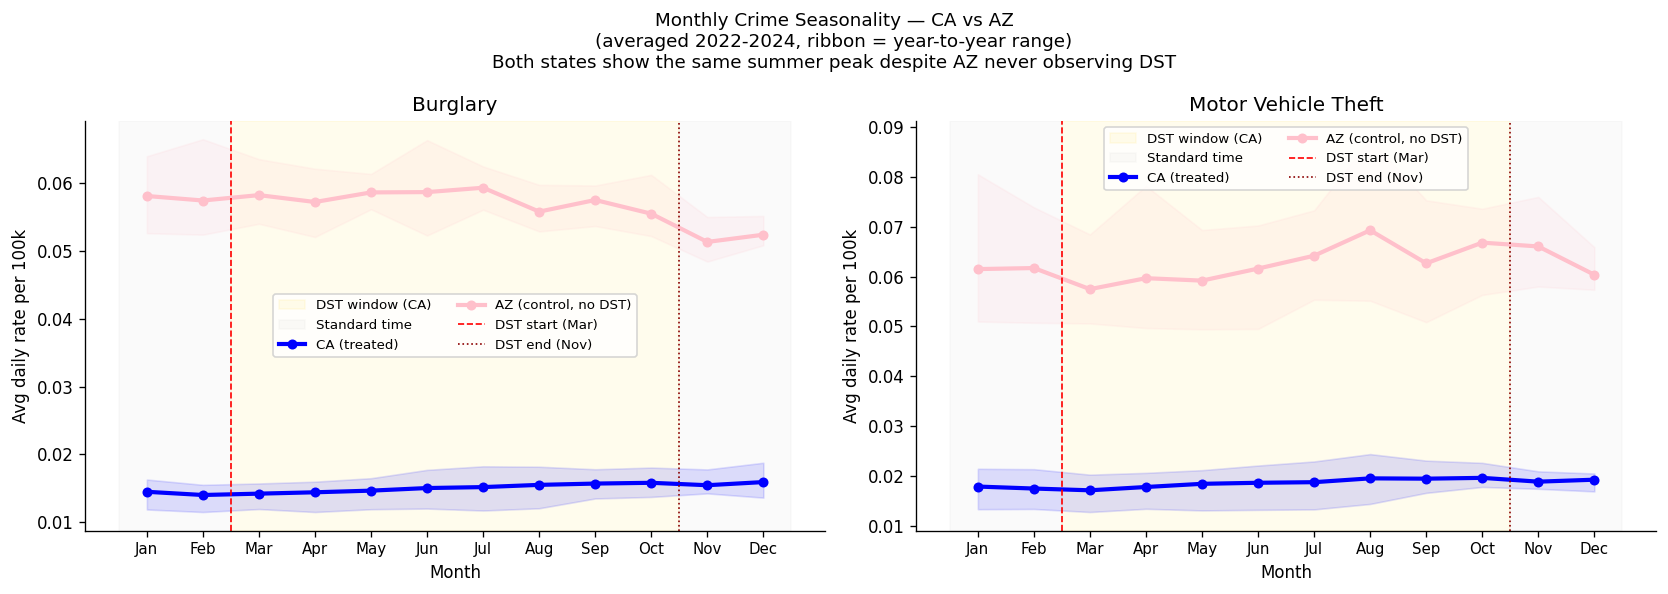


Summer (Jun-Aug) vs Winter (Dec-Feb) average rates:
State    Crime type                    Winter     Summer    Pct increase
----------------------------------------------------------------------
CA       Burglary                      0.0148     0.0152           +2.9%
CA       Motor Vehicle Theft           0.0182     0.0190           +4.2%
AZ       Burglary                      0.0560     0.0579           +3.5%
AZ       Motor Vehicle Theft           0.0612     0.0650           +6.3%


In [70]:
# ── Monthly seasonality — showing the confounding problem ──────────────────
# observing DST — proving the pattern is seasonal, not DST-driven

SEAS_PATH = Path("data/processed/analysis/monthly_seasonality_by_year.csv")
seas = pd.read_csv(SEAS_PATH)
seas = seas[
    seas["state"].isin(["CA", "AZ"]) &
    seas["crime_type"].isin(CRIMES)
].copy()

# Collapse across years
seas_avg = (
    seas.groupby(["state", "month", "crime_type"], as_index=False)
    .agg(
        avg_rate=("avg_daily_rate_per_100k", "mean"),
        lo_rate=("avg_daily_rate_per_100k", "min"),
        hi_rate=("avg_daily_rate_per_100k", "max"),
    )
)

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Monthly Crime Seasonality — CA vs AZ\n"
    "(averaged 2022-2024, ribbon = year-to-year range)\n"
    "Both states show the same summer peak despite AZ never observing DST",
    fontsize=11
)

for ax, ct in zip(axes, CRIMES):
    sub = seas_avg[seas_avg["crime_type"] == ct]

    # Shade DST window
    ax.axvspan(2.5, 10.5, alpha=0.07, color="gold",      zorder=0, label="DST window (CA)")
    ax.axvspan(0.5,  2.5, alpha=0.10, color="lightgray", zorder=0, label="Standard time")
    ax.axvspan(10.5, 12.5,alpha=0.10, color="lightgray", zorder=0)

    for state in ["CA", "AZ"]:
        s = sub[sub["state"] == state].sort_values("month")
        ax.plot(
            s["month"], s["avg_rate"],
            color=STATE_COLORS[state], lw=2.5, marker="o", ms=5,
            label=f"{state} ({'treated' if state == 'CA' else 'control, no DST'})"
        )
        ax.fill_between(
            s["month"], s["lo_rate"], s["hi_rate"],
            color=STATE_COLORS[state], alpha=0.12
        )

    ax.axvline(2.5,  color="red",     ls="--", lw=1.0, label="DST start (Mar)")
    ax.axvline(10.5, color="darkred", ls=":",  lw=1.0, label="DST end (Nov)")
    ax.set_title(CRIME_LABELS[ct])
    ax.set_xlabel("Month")
    ax.set_ylabel("Avg daily rate per 100k")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS, fontsize=9)
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print("\nSummer (Jun-Aug) vs Winter (Dec-Feb) average rates:")
print(f"{'State':<8} {'Crime type':<25} {'Winter':>10} {'Summer':>10} {'Pct increase':>15}")
print("-" * 70)
for state in ["CA", "AZ"]:
    for ct in CRIMES:
        sub = seas[
            (seas["state"] == state) &
            (seas["crime_type"] == ct)
        ]
        winter = sub[sub["month"].isin([12, 1, 2])]["avg_daily_rate_per_100k"].mean()
        summer = sub[sub["month"].isin([6, 7, 8])]["avg_daily_rate_per_100k"].mean()
        pct    = (summer - winter) / winter * 100
        print(f"{state:<8} {CRIME_LABELS[ct]:<25} {winter:>10.4f} {summer:>10.4f} {pct:>+14.1f}%")

## Section 2 — Parallel Trends Check

The key identifying assumption of DiD is **parallel trends**: in the absence of DST, CA and AZ crime rates would have evolved similarly.

We plot the CA minus AZ monthly crime rate gap using the pre-computed `parallel_trends_monthly.csv`. If parallel trends holds, the gap should be flat and stable in the pre-DST months (Nov–Feb). A systematic shift after March would indicate either a DST effect or a violation of the assumption.

The formal statistical test is in Section 5 (event study pre-period).

Columns: ['state', 'year', 'month', 'crime_type', 'mean_daily_rate_per_100k']
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
States: ['AZ', 'CA']
  state  year  month           crime_type  mean_daily_rate_per_100k
0    AZ  2022      1             burglary                   0.45851
1    AZ  2022      1  motor_vehicle_theft                   0.27485
6    AZ  2022      2             burglary                   0.52983


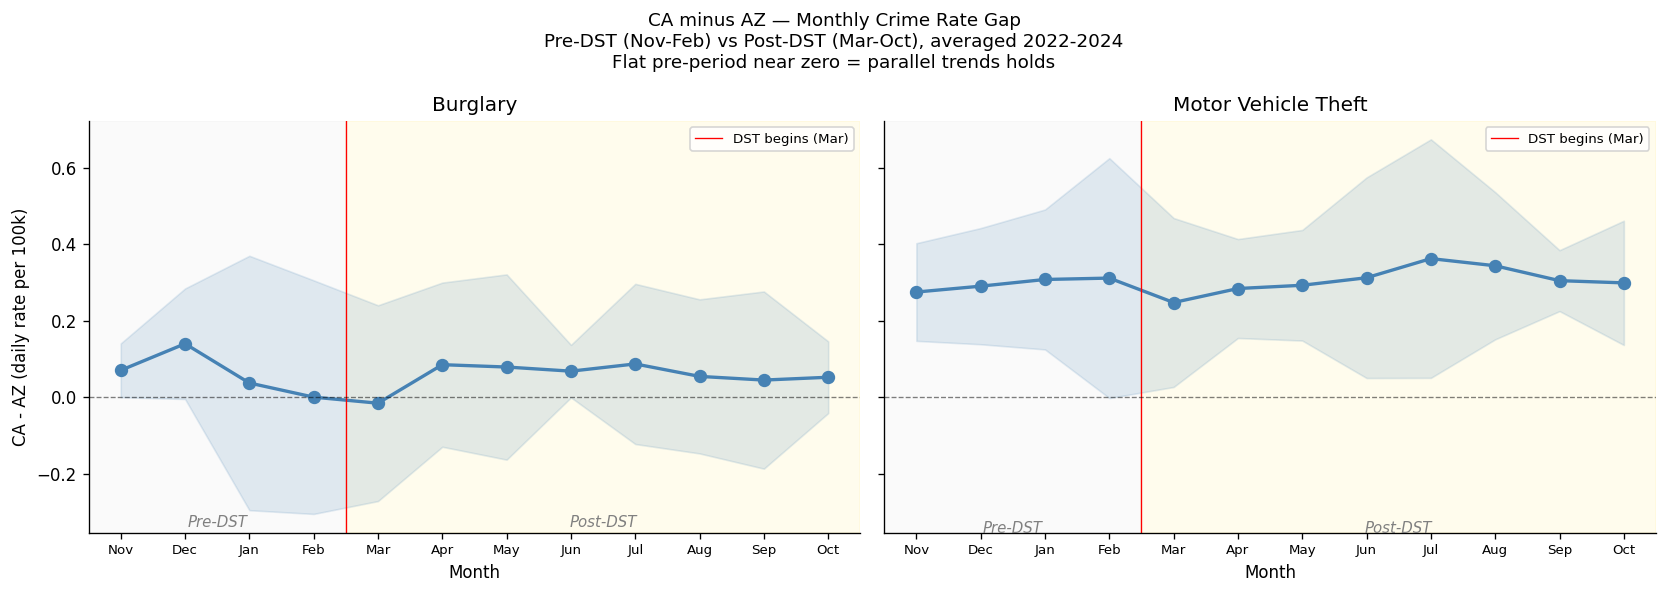

In [71]:
# ── Load parallel trends data ──────────────────────────────────────────────
trends = pd.read_csv(PT_PATH)
trends = trends[
    trends["state"].isin(["CA", "AZ"]) &
    trends["crime_type"].isin(CRIMES)
].copy()

print("Columns:", trends.columns.tolist())
print("Years:",   sorted(trends["year"].unique()))
print("States:",  sorted(trends["state"].unique()))
print(trends.head(3))

# ── Build CA minus AZ gap ──────────────────────────────────────────────────
PRE_MONTHS  = [11, 12, 1, 2]
POST_MONTHS = [3, 4, 5, 6, 7, 8, 9, 10]

monthly_gap = trends.pivot_table(
    index=["year", "month", "crime_type"],
    columns="state",
    values="mean_daily_rate_per_100k"
).reset_index()
monthly_gap["gap"] = monthly_gap["CA"] - monthly_gap["AZ"]

gap_avg = (
    monthly_gap.groupby(["month", "crime_type"], as_index=False)
    .agg(avg_gap=("gap", "mean"), se_gap=("gap", "std"))
)
gap_avg["ci_lo"] = gap_avg["avg_gap"] - 1.96 * gap_avg["se_gap"]
gap_avg["ci_hi"] = gap_avg["avg_gap"] + 1.96 * gap_avg["se_gap"]

pre_x  = {m: i+1 for i, m in enumerate(PRE_MONTHS)}
post_x = {m: i+5 for i, m in enumerate(POST_MONTHS)}
gap_avg["x_pos"] = gap_avg["month"].map({**pre_x, **post_x})

all_labels = ["Nov", "Dec", "Jan", "Feb",
              "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(
    "CA minus AZ — Monthly Crime Rate Gap\n"
    "Pre-DST (Nov-Feb) vs Post-DST (Mar-Oct), averaged 2022-2024\n"
    "Flat pre-period near zero = parallel trends holds",
    fontsize=11
)

for ax, ct in zip(axes, CRIMES):
    sub = gap_avg[gap_avg["crime_type"] == ct].sort_values("x_pos")
    ax.plot(sub["x_pos"], sub["avg_gap"],
            "o-", color="steelblue", lw=2, ms=7)
    ax.fill_between(sub["x_pos"], sub["ci_lo"], sub["ci_hi"],
                    color="steelblue", alpha=0.15)
    ax.axvline(4.5, color="red", lw=0.8, label="DST begins (Mar)")
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.axvspan(0.5,  4.5,  alpha=0.10, color="lightgray", zorder=0)
    ax.axvspan(4.5,  12.5, alpha=0.07, color="gold",      zorder=0)
    ax.text(2.5, ax.get_ylim()[0], "Pre-DST",
            ha="center", fontsize=9, color="gray", style="italic")
    ax.text(8.5, ax.get_ylim()[0], "Post-DST",
            ha="center", fontsize=9, color="gray", style="italic")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(all_labels, fontsize=8)
    ax.set_xlim(0.5, 12.5)
    ax.set_title(CRIME_LABELS[ct])
    ax.set_ylabel("CA - AZ (daily rate per 100k)" if ct == CRIMES[0] else "")
    ax.set_xlabel("Month")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Section 3 — Main TWFE DiD

**Specification:**

$$\text{rate}_{ct} = \beta \cdot \text{InDSTWindow}_{ct} + \gamma \cdot \text{Controls}_{ct} + \alpha_c + \lambda_{ym} + \varepsilon_{ct}$$

where $\alpha_c$ are county fixed effects and $\lambda_{ym}$ are year-month fixed effects. Standard errors are clustered at the county level.

The coefficient $\beta$ captures how much daily crime changed in CA during the DST window relative to AZ, after removing county-level differences and common time trends.

| Spec | Description |
|---|---|
| M1 Baseline | `in_dst_window + is_weekend + is_holiday + county FE + year-month FE` |
| M2 + Socio | M1 + median income, poverty rate, unemployment, education |
| M3 Log rate | M1 with log(crime rate) as outcome |
| M4 Year FE | M1 with year FE instead of year-month FE |

In [72]:
# ── TWFE helper functions ──────────────────────────────────────────────────
def run_twfe(df, outcome, regressors,
             entity="county_name", time="year_month", cluster="county_name"):
    """
    Two-way fixed effects OLS via within-transformation (FWL theorem).
    County FE absorbed first, then time FE.
    Standard errors clustered at county level.
    """
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d = df[cols].dropna(subset=[outcome] + regressors).copy()
    for c in [outcome] + regressors:
        d[c] = d[c].astype(float)

    # Absorb county FE
    e_means = d.groupby(entity)[[outcome] + regressors].transform("mean")
    d[[outcome] + regressors] = d[[outcome] + regressors] - e_means

    # Absorb time FE
    t_means = d.groupby(time)[[outcome] + regressors].transform("mean")
    d[[outcome] + regressors] = d[[outcome] + regressors] - t_means

    X      = sm.add_constant(d[regressors])
    groups = df.loc[d.index, cluster].values
    return sm.OLS(d[outcome], X).fit(
        cov_type="cluster", cov_kwds={"groups": groups}
    )


def results_table(results_dict, treatment_var="in_dst_window"):
    rows = []
    for label, res in results_dict.items():
        coef  = res.params.get(treatment_var, np.nan)
        se    = res.bse.get(treatment_var, np.nan)
        pval  = res.pvalues.get(treatment_var, np.nan)
        stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
        ci_lo, ci_hi = coef - 1.96*se, coef + 1.96*se
        rows.append({
            "Specification": label,
            "Coef":    round(coef, 5),
            "SE":      f"({round(se, 5)})",
            "Sig":     stars,
            "p-value": round(pval, 4),
            "95% CI":  f"[{ci_lo:.4f}, {ci_hi:.4f}]",
            "N":       int(res.nobs),
        })
    return pd.DataFrame(rows)


print("TWFE functions defined.")

TWFE functions defined.


In [73]:
# ── Run four specifications for each crime type ────────────────────────────
BASE_CONTROLS  = ["in_dst_window", "is_weekend", "is_holiday"]
SOCIO_CONTROLS = BASE_CONTROLS + [
    "median_household_income", "poverty_rate",
    "unemployment_rate",       "bachelors_plus_rate"
]

results = {}
for ct in CRIMES:
    sub = panel[panel["crime_type"] == ct].copy()
    results[f"{ct} | M1 Baseline"] = run_twfe(sub, "crime_rate_per_100k", BASE_CONTROLS)
    results[f"{ct} | M2 + Socio"]  = run_twfe(sub, "crime_rate_per_100k", SOCIO_CONTROLS)
    results[f"{ct} | M3 Log rate"] = run_twfe(sub, "log_rate",            BASE_CONTROLS)
    results[f"{ct} | M4 Year FE"]  = run_twfe(sub, "crime_rate_per_100k", BASE_CONTROLS, time="year")

print("=== MAIN TWFE RESULTS ===")
print(results_table(results).to_string(index=False))
print("\nFE: county + year-month (M1-M3), county + year (M4)")
print("SE clustered at county level. *** p<0.01, ** p<0.05, * p<0.1")

=== MAIN TWFE RESULTS ===
                    Specification     Coef        SE Sig  p-value            95% CI     N
           burglary | M1 Baseline -0.02470 (0.02452)      0.31360 [-0.0728, 0.0234] 39215
            burglary | M2 + Socio -0.00484 (0.01469)      0.74170 [-0.0336, 0.0240] 39215
           burglary | M3 Log rate -0.01462 (0.01049)      0.16360 [-0.0352, 0.0059] 39215
            burglary | M4 Year FE -0.01005 (0.00958)      0.29410 [-0.0288, 0.0087] 39215
motor_vehicle_theft | M1 Baseline -0.01076 (0.02232)      0.62980 [-0.0545, 0.0330] 40271
 motor_vehicle_theft | M2 + Socio  0.00788 (0.01287)      0.54030 [-0.0173, 0.0331] 40271
motor_vehicle_theft | M3 Log rate -0.00402  (0.0102)      0.69360 [-0.0240, 0.0160] 40271
 motor_vehicle_theft | M4 Year FE  0.01835  (0.0138)      0.18370 [-0.0087, 0.0454] 40271

FE: county + year-month (M1-M3), county + year (M4)
SE clustered at county level. *** p<0.01, ** p<0.05, * p<0.1


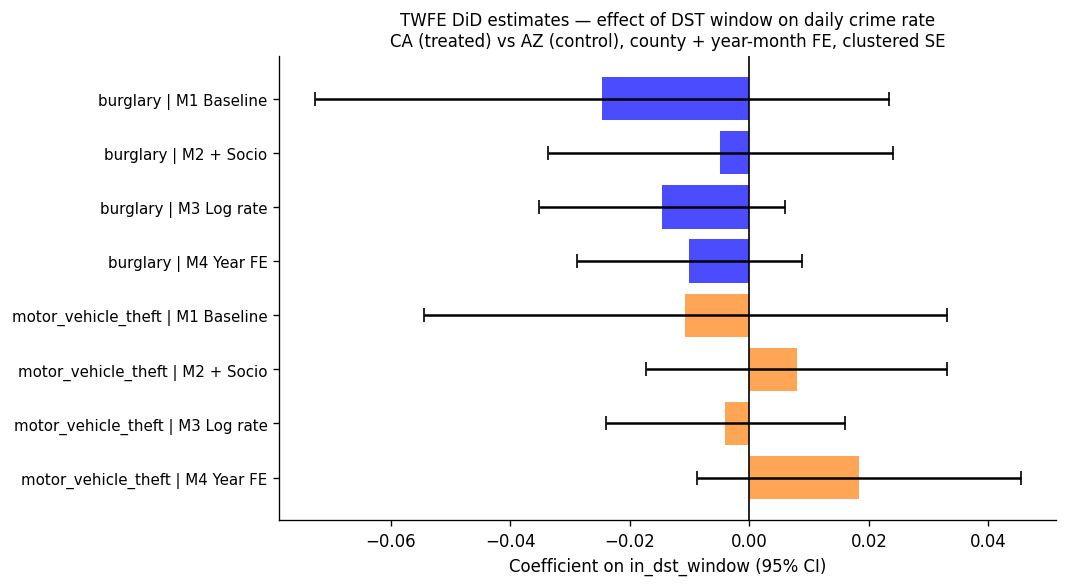

In [74]:
# ── Coefficient plot ───────────────────────────────────────────────────────
labels = list(results.keys())
coefs  = np.array([results[k].params.get("in_dst_window", np.nan) for k in labels])
ci95   = 1.96 * np.array([results[k].bse.get("in_dst_window", np.nan) for k in labels])
colors = [STATE_COLORS["CA"] if i < 4 else "#ff7f0e" for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(9, max(5, 0.45 * len(labels))))
y_pos = np.arange(len(labels))[::-1]
ax.barh(y_pos, coefs, xerr=ci95, color=colors, alpha=0.7,
        error_kw={"elinewidth": 1.5, "capsize": 4})
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Coefficient on in_dst_window (95% CI)")
ax.set_title(
    "TWFE DiD estimates — effect of DST window on daily crime rate\n"
    "CA (treated) vs AZ (control), county + year-month FE, clustered SE",
    fontsize=10
)
plt.tight_layout()
plt.show()

## Section 3.2 — Hourly Mechanism Test

The proposal's core hypothesis is that DST deters crime through the **daylight mechanism**: extending evening light reduces criminal opportunity. If this is real, DST should shift *when* crime happens, not just how much.

Using the pre-computed `hourly_by_dst_period_year.csv`, we compare crime across six time-of-day buckets in CA vs AZ between standard time and DST periods:

| Bucket | Hours | Expected effect under DST |
|---|---|---|
| Late night | 10pm–2am | Unaffected — should show no change |
| Early morning | 2am–6am | Gets darker after spring-forward — crime may rise |
| Morning | 6am–9am | Gets darker after spring-forward — crime may rise |
| Mid morning | 9am–12pm | Unaffected — should show no change |
| Afternoon | 12pm–5pm | Unaffected — should show no change |
| Evening | 5pm–10pm | Gets lighter after spring-forward — crime may fall |

This is averaged across 2022, 2023, and 2024 and is a mechanism diagnostic rather than a primary causal estimate.

Columns: ['state', 'year', 'hour', 'offense_type', 'period', 'crime_count', 'data_year', 'population', 'crime_rate_per_100k']
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
States: ['AZ', 'CA']
Periods: ['DST', 'standard']


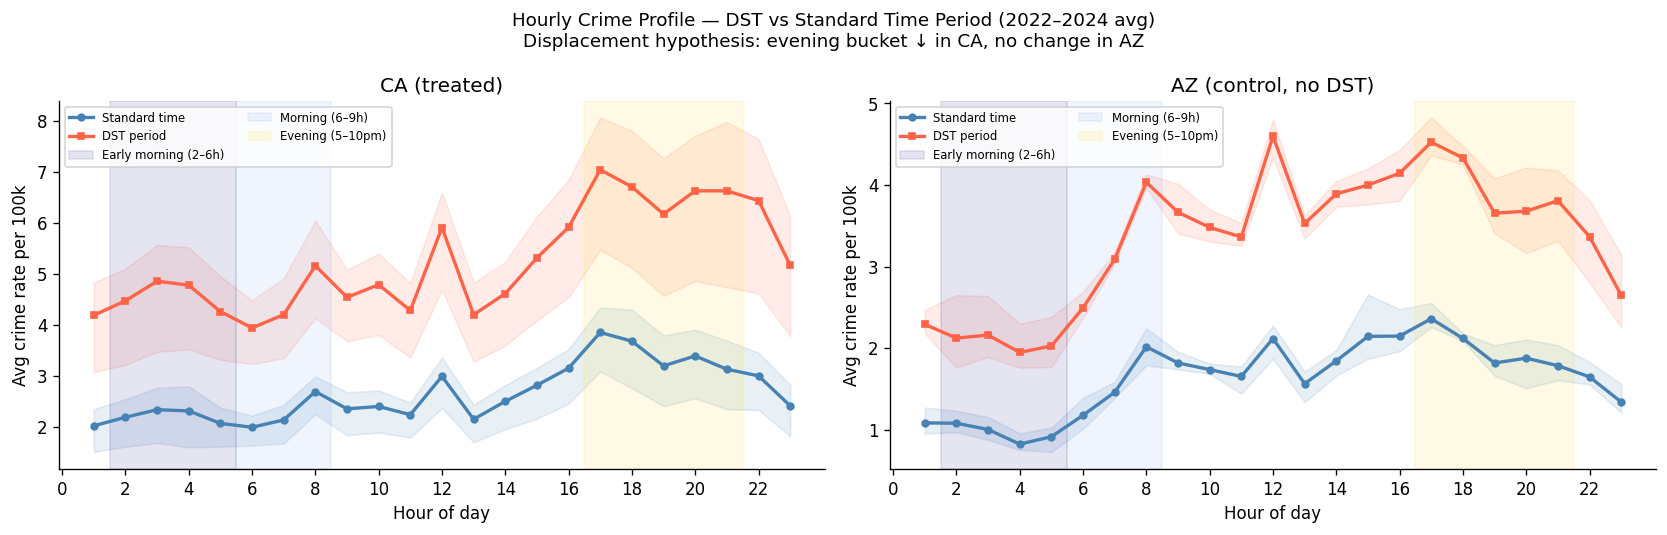


Bucket summary — CA (treated):
period         standard_time     dst  pct_change
time_bucket                                     
late_night           2.48353 5.26668   112.10000
early_morning        2.23248 4.59498   105.80000
morning              2.27922 4.43624    94.60000
mid_morning          2.33647 4.53967    94.30000
afternoon            2.72669 5.19195    90.40000
evening              3.45390 6.63540    92.10000

Bucket summary — AZ (control):
period         standard_time     dst  pct_change
time_bucket                                     
late_night           1.35894 2.76945   103.80000
early_morning        0.95688 2.06548   115.90000
morning              1.55241 3.20611   106.50000
mid_morning          1.73738 3.50245   101.60000
afternoon            1.96468 4.03187   105.20000
evening              1.99329 3.99909   100.60000


In [75]:
# ── Load hourly data from analysis folder ──────────────────────────────────
h = pd.read_csv(HOURLY_PATH)
h = h[
    h["state"].isin(["CA", "AZ"]) &
    h["offense_type"].isin(CRIMES)
].copy()

print("Columns:", h.columns.tolist())
print("Years:",   sorted(h["year"].unique()))
print("States:",  sorted(h["state"].unique()))
print("Periods:", sorted(h["period"].unique()))

# ── Hourly profile plot with year-to-year ribbon ───────────────────────────
hours = list(range(24))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(
    "Hourly Crime Profile — DST vs Standard Time Period (2022–2024 avg)\n"
    "Displacement hypothesis: evening bucket ↓ in CA, no change in AZ",
    fontsize=11
)

for ax, state in zip(axes, ["CA", "AZ"]):
    sub   = h[h["state"] == state]
    label = "CA (treated)" if state == "CA" else "AZ (control, no DST)"

    for period, color, marker, lbl in [
        ("standard", "steelblue", "o", "Standard time"),
        ("DST",      "tomato",    "s", "DST period"),
    ]:
        period_sub = sub[sub["period"] == period]

        # Average line across years and crime types
        avg = (
            period_sub.groupby("hour")["crime_rate_per_100k"]
            .mean().reindex(range(24))
        )
        # Min and max across years for ribbon
        lo = (
            period_sub.groupby(["year", "hour"])["crime_rate_per_100k"]
            .mean().groupby("hour").min().reindex(range(24))
        )
        hi = (
            period_sub.groupby(["year", "hour"])["crime_rate_per_100k"]
            .mean().groupby("hour").max().reindex(range(24))
        )

        ax.plot(hours, avg.values, color=color, lw=2,
                marker=marker, ms=4, label=lbl)
        ax.fill_between(hours, lo.values, hi.values,
                        color=color, alpha=0.12)

    ax.axvspan(1.5,  5.5,  alpha=0.10, color="navy",          label="Early morning (2–6h)")
    ax.axvspan(5.5,  8.5,  alpha=0.10, color="cornflowerblue",label="Morning (6–9h)")
    ax.axvspan(16.5, 21.5, alpha=0.10, color="gold",          label="Evening (5–10pm)")
    ax.set_title(label)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Avg crime rate per 100k")
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# ── Six bucket analysis ────────────────────────────────────────────────────
def assign_bucket(hour):
    if hour >= 22 or hour < 2:  return "late_night"
    elif 2  <= hour < 6:        return "early_morning"
    elif 6  <= hour < 9:        return "morning"
    elif 9  <= hour < 12:       return "mid_morning"
    elif 12 <= hour < 17:       return "afternoon"
    else:                       return "evening"

h["time_bucket"] = h["hour"].apply(assign_bucket)

BUCKET_ORDER  = ["late_night", "early_morning", "morning",
                 "mid_morning", "afternoon", "evening"]
BUCKET_LABELS = {
    "late_night":    "Late night\n(10pm–2am)",
    "early_morning": "Early morning\n(2am–6am)",
    "morning":       "Morning\n(6am–9am)",
    "mid_morning":   "Mid morning\n(9am–12pm)",
    "afternoon":     "Afternoon\n(12pm–5pm)",
    "evening":       "Evening\n(5pm–10pm)",
}

def bucket_summary(df, state):
    sub = df[df["state"] == state]
    tbl = (
        sub.groupby(["time_bucket", "period"])["crime_rate_per_100k"]
        .mean().unstack(fill_value=0)
        .rename(columns={"standard": "standard_time", "DST": "dst"})
    )
    tbl["pct_change"] = (
        (tbl["dst"] - tbl["standard_time"]) /
        tbl["standard_time"].replace(0, np.nan) * 100
    ).round(1)
    return tbl.reindex(BUCKET_ORDER)

tbl_ca = bucket_summary(h, "CA")
tbl_az = bucket_summary(h, "AZ")

print("\nBucket summary — CA (treated):")
print(tbl_ca[["standard_time", "dst", "pct_change"]].to_string())
print("\nBucket summary — AZ (control):")
print(tbl_az[["standard_time", "dst", "pct_change"]].to_string())

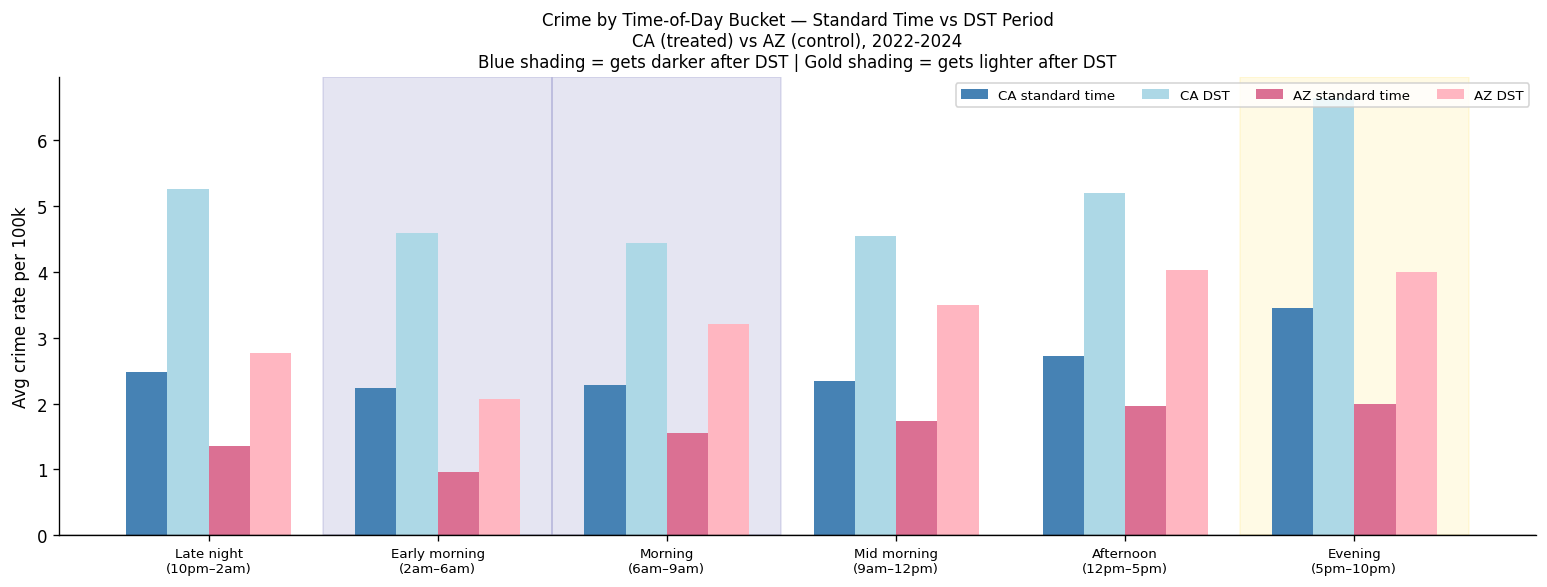


Note: averaged across 2022, 2023, and 2024.
This is a mechanism diagnostic, not a causal estimate.


In [76]:
# ── Six bucket bar chart ───────────────────────────────────────────────────
x = np.arange(len(BUCKET_ORDER))
w = 0.18

fig, ax = plt.subplots(figsize=(13, 5))
for offset, vals, color, label in [
    (-1.5*w, tbl_ca["standard_time"], "steelblue",     "CA standard time"),
    (-0.5*w, tbl_ca["dst"],           "lightblue",     "CA DST"),
    ( 0.5*w, tbl_az["standard_time"], "palevioletred", "AZ standard time"),
    ( 1.5*w, tbl_az["dst"],           "lightpink",     "AZ DST"),
]:
    ax.bar(x + offset, vals.reindex(BUCKET_ORDER).values,
           w, color=color, label=label)

ax.axvspan(0.5, 1.5, alpha=0.10, color="navy", zorder=0)
ax.axvspan(1.5, 2.5, alpha=0.10, color="navy", zorder=0)
ax.axvspan(4.5, 5.5, alpha=0.10, color="gold", zorder=0)

ax.set_xticks(x)
ax.set_xticklabels([BUCKET_LABELS[b] for b in BUCKET_ORDER], fontsize=8)
ax.set_ylabel("Avg crime rate per 100k")
ax.set_title(
    "Crime by Time-of-Day Bucket — Standard Time vs DST Period\n"
    "CA (treated) vs AZ (control), 2022-2024\n"
    "Blue shading = gets darker after DST | Gold shading = gets lighter after DST",
    fontsize=10
)
ax.legend(fontsize=8, ncol=4, loc="upper right")
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

print("\nNote: averaged across 2022, 2023, and 2024.")
print("This is a mechanism diagnostic, not a causal estimate.")

## Section 3.3 Daily Crime around Spring-forward

As a complementary mechanism check, we use `dst_transition_window.csv` which has daily crime rates centered around each year's spring-forward (day 0 = clock change), ±14 days. Restricting to ±14 days removes almost all seasonal confounding — the only thing that changes at day 0 is the clock. Comparing CA and AZ within this window directly tests whether the clock change caused a detectable shift in daily crime.

Shape: (1044, 7)
Days range: -14 to 14
States: ['AZ', 'CA']
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]


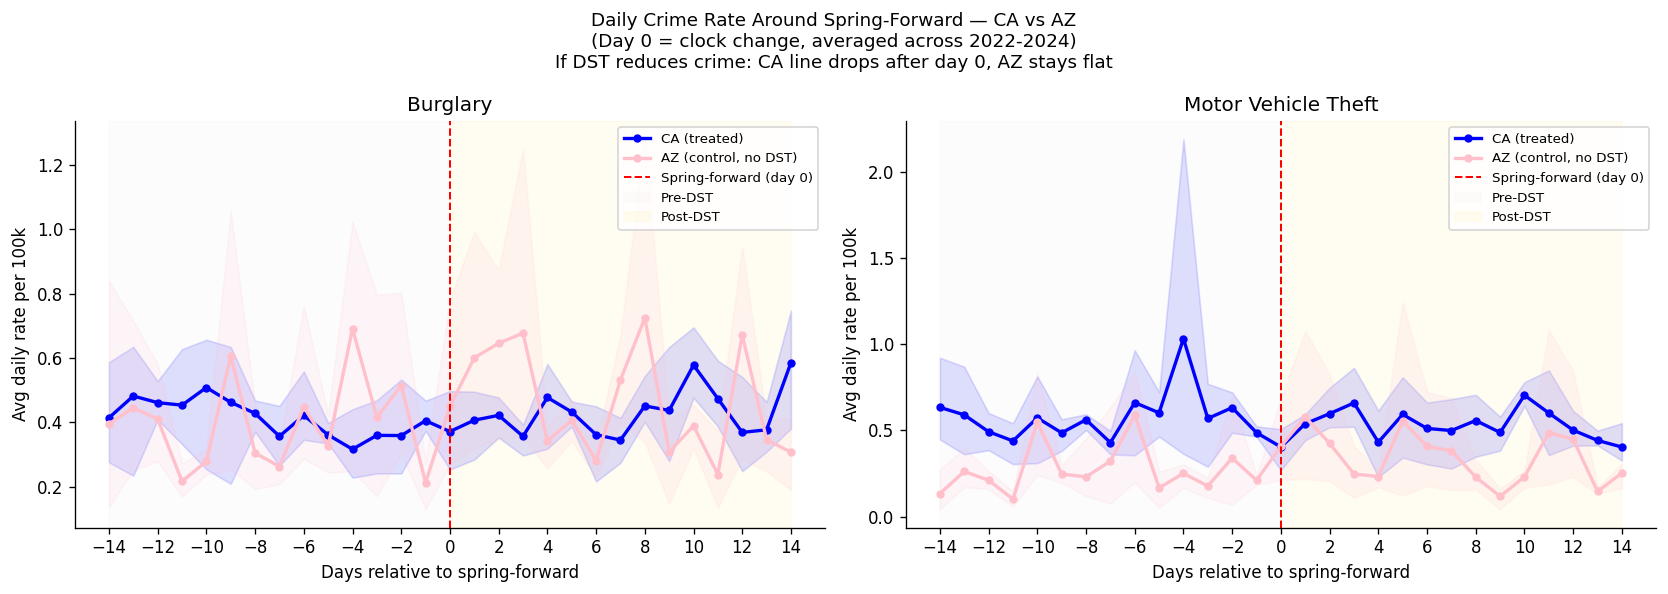

In [77]:
# ── Section 3.3: Daily crime around spring-forward — CA vs AZ ─────────────
# Uses dst_transition_window.csv which has daily crime rates centered around
# each year's spring-forward (day 0 = clock change), ±14 days.
# CA vs AZ comparison removes seasonal confounding — only the clock differs.

TRANSITION_PATH = Path("data/processed/analysis/dst_transition_window.csv")

tw = pd.read_csv(TRANSITION_PATH)
tw = tw[tw["state"].isin(["CA", "AZ"])].copy()

print("Shape:", tw.shape)
print("Days range:", tw["days_from_transition"].min(), "to", tw["days_from_transition"].max())
print("States:", sorted(tw["state"].unique()))
print("Years:", sorted(tw["year"].unique()))

# Collapse across years — mean rate per day-relative-to-transition
tw_avg = (
    tw.groupby(["state", "days_from_transition", "crime_type"], as_index=False)
    .agg(
        avg_rate=("avg_daily_rate_per_100k", "mean"),
        lo_rate=("avg_daily_rate_per_100k", "min"),
        hi_rate=("avg_daily_rate_per_100k", "max"),
    )
)

# ── Plot 1: Daily crime rates around spring-forward for CA and AZ ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Daily Crime Rate Around Spring-Forward — CA vs AZ\n"
    "(Day 0 = clock change, averaged across 2022-2024)\n"
    "If DST reduces crime: CA line drops after day 0, AZ stays flat",
    fontsize=11
)

for ax, ct in zip(axes, CRIMES):
    sub = tw_avg[tw_avg["crime_type"] == ct]

    for state in ["CA", "AZ"]:
        s = sub[sub["state"] == state].sort_values("days_from_transition")
        ax.plot(
            s["days_from_transition"], s["avg_rate"],
            color=STATE_COLORS[state], lw=2, marker="o", ms=4,
            label=f"{state} ({'treated' if state == 'CA' else 'control, no DST'})"
        )
        ax.fill_between(
            s["days_from_transition"], s["lo_rate"], s["hi_rate"],
            color=STATE_COLORS[state], alpha=0.12
        )

    ax.axvline(0, color="red", lw=1.2, ls="--", label="Spring-forward (day 0)")
    ax.axvspan(-14, 0, alpha=0.05, color="lightgray", zorder=0, label="Pre-DST")
    ax.axvspan(0,  14, alpha=0.05, color="gold",      zorder=0, label="Post-DST")
    ax.set_title(CRIME_LABELS[ct])
    ax.set_xlabel("Days relative to spring-forward")
    ax.set_ylabel("Avg daily rate per 100k")
    ax.set_xticks(range(-14, 15, 2))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

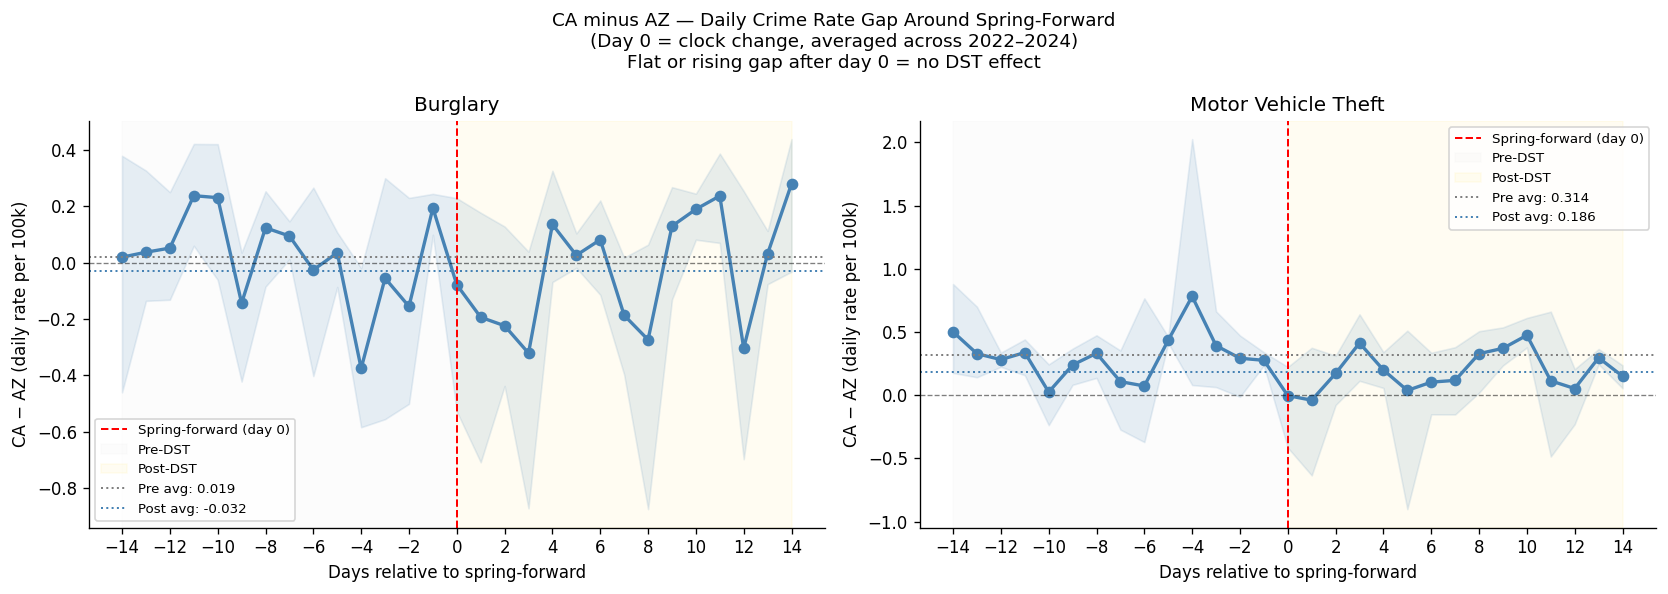

In [78]:
# ── Plot 2: CA minus AZ gap plot with year-to-year ribbon ─────────────────
# Compute gap per year first, then get avg, min, max across years
tw_gap_yr = tw.pivot_table(
    index=["year", "days_from_transition", "crime_type"],
    columns="state",
    values="avg_daily_rate_per_100k"
).reset_index()
tw_gap_yr["gap"] = tw_gap_yr["CA"] - tw_gap_yr["AZ"]

tw_gap = (
    tw_gap_yr.groupby(["days_from_transition", "crime_type"], as_index=False)
    .agg(
        avg_gap=("gap", "mean"),
        lo_gap=("gap", "min"),
        hi_gap=("gap", "max"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "CA minus AZ — Daily Crime Rate Gap Around Spring-Forward\n"
    "(Day 0 = clock change, averaged across 2022–2024)\n"
    "Flat or rising gap after day 0 = no DST effect",
    fontsize=11
)

for ax, ct in zip(axes, CRIMES):
    sub = tw_gap[tw_gap["crime_type"] == ct].sort_values("days_from_transition")

    # Line with ribbon
    ax.plot(sub["days_from_transition"], sub["avg_gap"],
            "o-", color="steelblue", lw=2, ms=6)
    ax.fill_between(sub["days_from_transition"], sub["lo_gap"], sub["hi_gap"],
                    color="steelblue", alpha=0.12)

    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.axvline(0, color="red", lw=1.2, ls="--", label="Spring-forward (day 0)")
    ax.axvspan(-14, 0, alpha=0.05, color="lightgray", zorder=0, label="Pre-DST")
    ax.axvspan(0,  14, alpha=0.05, color="gold",      zorder=0, label="Post-DST")

    pre_avg  = sub[sub["days_from_transition"] <  0]["avg_gap"].mean()
    post_avg = sub[sub["days_from_transition"] >= 0]["avg_gap"].mean()
    ax.axhline(pre_avg,  color="gray",      ls=":", lw=1.2,
               label=f"Pre avg: {pre_avg:.3f}")
    ax.axhline(post_avg, color="steelblue", ls=":", lw=1.2,
               label=f"Post avg: {post_avg:.3f}")

    ax.set_title(CRIME_LABELS[ct])
    ax.set_xlabel("Days relative to spring-forward")
    ax.set_ylabel("CA − AZ (daily rate per 100k)")
    ax.set_xticks(range(-14, 15, 2))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Evening and Morning Crime Share — DST vs Standard Time:

State  Crime type                Period         Evening share   Morning share
---------------------------------------------------------------------------
AZ     Burglary                  DST                    0.229           0.218
AZ     Burglary                  standard               0.239           0.199
AZ     Motor Vehicle Theft       DST                    0.293           0.180
AZ     Motor Vehicle Theft       standard               0.292           0.194
CA     Burglary                  DST                    0.235           0.191
CA     Burglary                  standard               0.243           0.192
CA     Motor Vehicle Theft       DST                    0.306           0.179
CA     Motor Vehicle Theft       standard               0.313           0.179


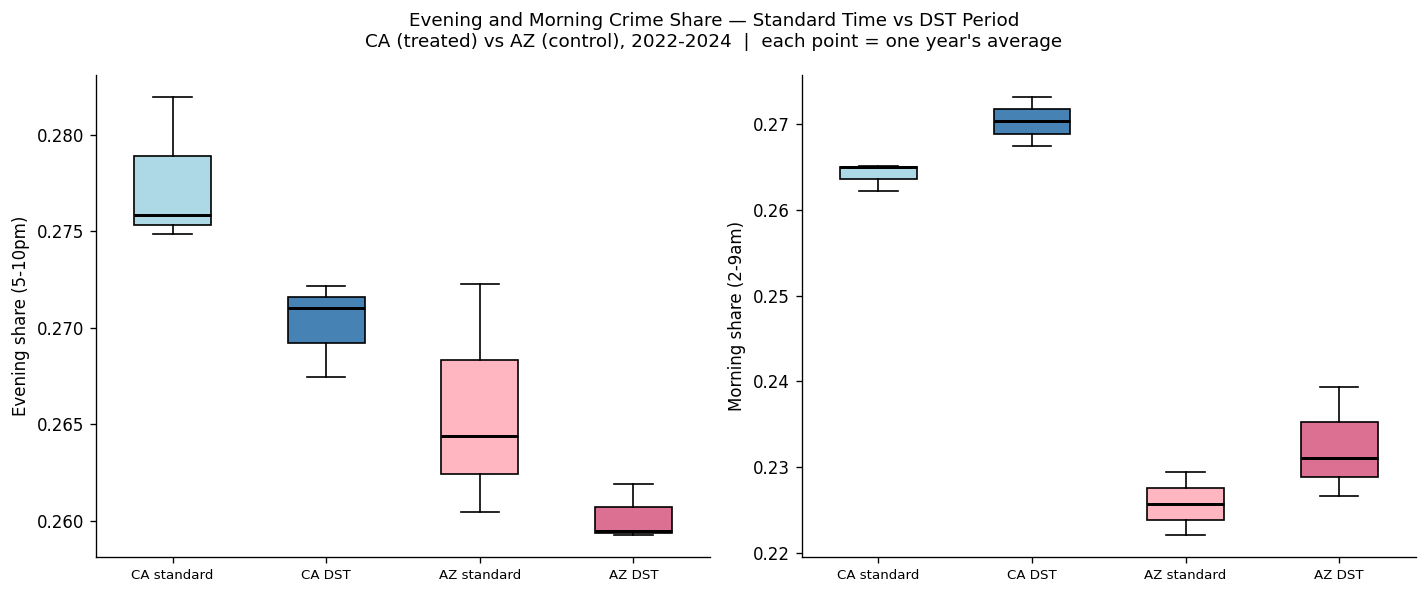


DiD interpretation — change in evening share (DST minus standard time):
State  Crime type                  Evening share change    Direction
----------------------------------------------------------------------
CA     Burglary                                 -0.0074         fell
CA     Motor Vehicle Theft                      -0.0069         fell
AZ     Burglary                                 -0.0101         fell
AZ     Motor Vehicle Theft                      +0.0004         rose


In [79]:
# ── Evening and morning share summary ─────────────────────────────────────
SHARE_PATH = Path("data/processed/analysis/evening_morning_share.csv")
share = pd.read_csv(SHARE_PATH)
share = share[
    share["state"].isin(["CA", "AZ"]) &
    share["offense_type"].isin(CRIMES)
].copy()

# ── Print table ────────────────────────────────────────────────────────────
print("Evening and Morning Crime Share — DST vs Standard Time:")
print(f"\n{'State':<6} {'Crime type':<25} {'Period':<12} {'Evening share':>15} {'Morning share':>15}")
print("-" * 75)
for _, row in share.sort_values(["state", "offense_type", "period"]).iterrows():
    print(f"{row['state']:<6} {CRIME_LABELS[row['offense_type']]:<25} "
          f"{row['period']:<12} {row['evening_share']:>15.3f} {row['morning_share']:>15.3f}")

# ── Compute shares from pre-aggregated hourly data ─────────────────────────
# evening_crime_panel only tracks evening_count; compute both metrics from
# hourly_by_dst_period_year which has crime_rate_per_100k by hour/year/period
h = pd.read_csv(Path("data/processed/analysis/hourly_by_dst_period_year.csv"))
h = h[h["state"].isin(["CA", "AZ"]) & h["offense_type"].isin(CRIMES)].copy()

EVENING_HRS = list(range(17, 22))
MORNING_HRS = list(range(2, 9))
KEY = ["state", "offense_type", "period", "year"]

total   = h.groupby(KEY)["crime_rate_per_100k"].sum().rename("total")
evening = h[h["hour"].isin(EVENING_HRS)].groupby(KEY)["crime_rate_per_100k"].sum().rename("evening")
morning = h[h["hour"].isin(MORNING_HRS)].groupby(KEY)["crime_rate_per_100k"].sum().rename("morning")

share_yr = pd.concat([total, evening, morning], axis=1).reset_index()
share_yr["evening_share"] = share_yr["evening"] / share_yr["total"]
share_yr["morning_share"] = share_yr["morning"] / share_yr["total"]

# Average across crime types -> one value per (state, period, year)
box_data = (
    share_yr.groupby(["state", "period", "year"])[["evening_share", "morning_share"]]
    .mean()
    .reset_index()
)

# ── Box plot ───────────────────────────────────────────────────────────────
BOX_COLORS = {
    ("CA", "standard"): "lightblue",
    ("CA", "DST"):       "steelblue",
    ("AZ", "standard"): "lightpink",
    ("AZ", "DST"):       "palevioletred",
}
BOX_LABELS = {
    ("CA", "standard"): "CA standard",
    ("CA", "DST"):       "CA DST",
    ("AZ", "standard"): "AZ standard",
    ("AZ", "DST"):       "AZ DST",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Evening and Morning Crime Share — Standard Time vs DST Period\n"
    "CA (treated) vs AZ (control), 2022-2024  |  each point = one year's average",
    fontsize=11
)

for ax, metric, ylabel in zip(axes,
    ["evening_share", "morning_share"],
    ["Evening share (5-10pm)", "Morning share (2-9am)"]
):
    groups, tick_labels, tick_colors = [], [], []
    for state in ["CA", "AZ"]:
        for period in ["standard", "DST"]:
            vals = box_data[
                (box_data["state"]  == state) &
                (box_data["period"] == period)
            ][metric].dropna().values
            groups.append(vals)
            tick_labels.append(BOX_LABELS[(state, period)])
            tick_colors.append(BOX_COLORS[(state, period)])

    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.8))
    for patch, color in zip(bp["boxes"], tick_colors):
        patch.set_facecolor(color)

    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

# ── DiD interpretation ─────────────────────────────────────────────────────
print("\nDiD interpretation — change in evening share (DST minus standard time):")
print(f"{'State':<6} {'Crime type':<25} {'Evening share change':>22} {'Direction':>12}")
print("-" * 70)
for state in ["CA", "AZ"]:
    for ct in CRIMES:
        sub = share[
            (share["state"] == state) &
            (share["offense_type"] == ct)
        ]
        dst = sub[sub["period"] == "DST"]["evening_share"].values[0]
        std = sub[sub["period"] == "standard"]["evening_share"].values[0]
        chg = dst - std
        direction = "fell" if chg < 0 else "rose"
        print(f"{state:<6} {CRIME_LABELS[ct]:<25} {chg:>+22.4f} {direction:>12}")

## Section 4 — Narrow-Window Check

Restricts the sample to observations within ±7, ±15, ±21, and ±30 days of the spring-forward date. Within such a short window the season barely changes — only the clocks do — so any estimated effect is more cleanly attributable to DST itself rather than seasonal confounding.

In [80]:
window_results = {}
for ct in CRIMES:
    sub = panel[panel["crime_type"] == ct].copy()
    for window in [7, 15, 21, 30]:
        win_sub = sub[sub["days_from_dst_start"].abs() <= window].copy()
        window_results[f"{CRIME_LABELS[ct]} | ±{window}d"] = run_twfe(
            win_sub, "crime_rate_per_100k", BASE_CONTROLS, time="year"
        )

print("=== NARROW-WINDOW RESULTS ===")
print(results_table(window_results).to_string(index=False))
print("\nFE: county + year. SE clustered at county level.")
print("Null here + null in full-year model → genuine null result, not seasonality confound.")

=== NARROW-WINDOW RESULTS ===
             Specification     Coef        SE Sig  p-value            95% CI    N
            Burglary | ±7d -0.02196 (0.03003)      0.46450 [-0.0808, 0.0369] 1529
           Burglary | ±15d  0.00234 (0.02319)      0.91960 [-0.0431, 0.0478] 3192
           Burglary | ±21d  0.00133 (0.01924)      0.94500 [-0.0364, 0.0390] 4405
           Burglary | ±30d -0.00630  (0.0166)      0.70420 [-0.0388, 0.0262] 6292
 Motor Vehicle Theft | ±7d  0.02936 (0.02615)      0.26150 [-0.0219, 0.0806] 1629
Motor Vehicle Theft | ±15d  0.01019 (0.01883)      0.58830 [-0.0267, 0.0471] 3317
Motor Vehicle Theft | ±21d -0.01860 (0.01872)      0.32050 [-0.0553, 0.0181] 4616
Motor Vehicle Theft | ±30d -0.01117 (0.01557)      0.47280 [-0.0417, 0.0193] 6585

FE: county + year. SE clustered at county level.
Null here + null in full-year model → genuine null result, not seasonality confound.


## Section 5 — Event Study

Dynamic DiD estimating week-by-week treatment effects around the spring-forward. Two things to look for:
- **Pre-period (weeks < 0):** coefficients near zero validates parallel trends
- **Post-period (weeks ≥ 0):** any shift indicates a DST effect

Reference bin: week −1 (the week immediately before spring-forward).

In [81]:
# ── Event study helper functions ───────────────────────────────────────────
def run_event_study(df, outcome, entity="county_name", time="year",
                    cluster="county_name", clip=(-8, 8), ref_bin=-1):
    d = df.copy()
    d["week_rel"] = (d["days_from_dst_start"] // 7).clip(*clip)
    d["treated"]  = (d["state"] == "CA").astype(float)
    bins = [b for b in sorted(d["week_rel"].dropna().unique()) if b != ref_bin]

    dum_cols = []
    for b in bins:
        col = f"tw_{b:+d}"
        d[col] = d["treated"] * (d["week_rel"] == b).astype(float)
        dum_cols.append(col)

    regressors = dum_cols + ["is_weekend", "is_holiday"]
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform("mean")
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform("mean")
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X      = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res    = sm.OLS(d2[outcome], X).fit(
        cov_type="cluster", cov_kwds={"groups": groups}
    )

    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({"week": b, "coef": res.params[col],
                         "se": res.bse[col], "ci_lo": ci[0],
                         "ci_hi": ci[1], "pval": res.pvalues[col]})
    rows.append({"week": ref_bin, "coef": 0.0, "se": 0.0,
                 "ci_lo": 0.0, "ci_hi": 0.0, "pval": 1.0})
    return pd.DataFrame(rows).sort_values("week").reset_index(drop=True)


def plot_event_study(es_df, title, ax):
    ax.fill_between(es_df["week"], es_df["ci_lo"], es_df["ci_hi"],
                    alpha=0.2, color="steelblue")
    ax.plot(es_df["week"], es_df["coef"],
            "o-", color="steelblue", lw=2, ms=5)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(-0.5, color="red", ls="--", lw=1, label="Spring-forward")
    ax.axvspan(-8, -0.5, alpha=0.05, color="gray", label="Pre-period")
    ax.set_xlabel("Weeks relative to spring-forward")
    ax.set_ylabel("DiD coefficient (rate per 100k)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)


print("Event study functions defined.")

Event study functions defined.


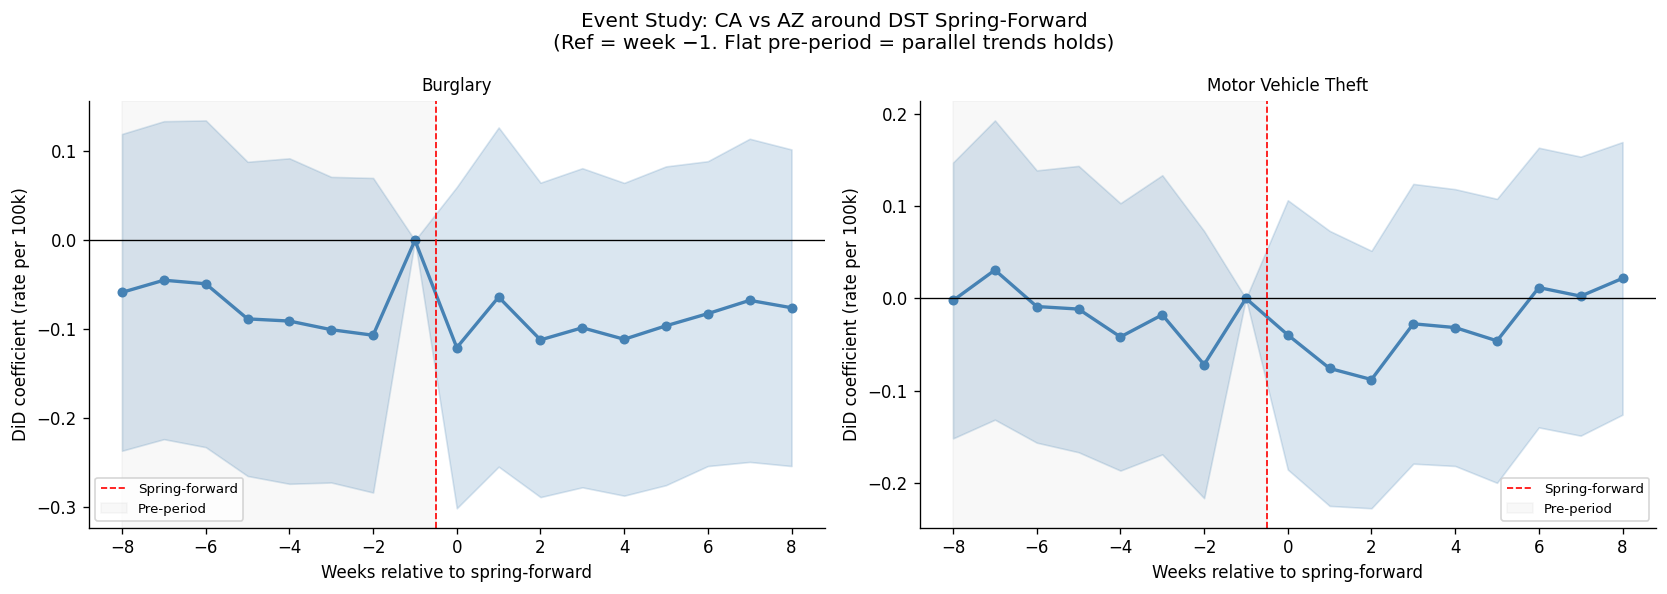


Pre-trend test (weeks -8 to -2):
Crime type                Significant bins (p<0.1)  Result
-----------------------------------------------------------------
Burglary                  0/7 bins at p<0.1        ✓ Passes
Motor Vehicle Theft       0/7 bins at p<0.1        ✓ Passes


In [82]:
# ── Run and plot event studies ─────────────────────────────────────────────
es_results = {}
for ct in CRIMES:
    es_results[ct] = run_event_study(
        panel[panel["crime_type"] == ct], "crime_rate_per_100k"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Event Study: CA vs AZ around DST Spring-Forward\n"
    "(Ref = week −1. Flat pre-period = parallel trends holds)",
    fontsize=12
)
for ax, ct in zip(axes, CRIMES):
    plot_event_study(es_results[ct], CRIME_LABELS[ct], ax)
plt.tight_layout()
plt.show()

# ── Joint pre-trend test ───────────────────────────────────────────────────
print("\nPre-trend test (weeks -8 to -2):")
print(f"{'Crime type':<25} {'Significant bins (p<0.1)':<25} Result")
print("-" * 65)
for ct in CRIMES:
    pre  = es_results[ct][es_results[ct]["week"] <= -2]
    sig  = (pre["pval"] < 0.1).sum()
    flag = "⚠ May be violated" if sig >= 3 else "✓ Passes"
    print(f"{CRIME_LABELS[ct]:<25} {sig}/{len(pre)} bins at p<0.1        {flag}")

## Section 6 — Robustness Checks

Four checks to test whether the null result is sensitive to specification choices:

1. **Exclude holidays** — removes days with atypical crime patterns unrelated to DST
2. **Weekdays only** — weekends have different crime structures
3. **Placebo (standard-time window)** — assigns CA the fake treatment during Nov–Feb when DST is not active. A real DST effect should not appear here. Null result validates the design.
4. **Exclude transition fortnight** — drops ±7 days around spring-forward to isolate the sustained daylight effect from any short-run offender-fatigue effect (Munyo 2018)

In [83]:
robust_results = {}
for ct in CRIMES:
    sub   = panel[panel["crime_type"] == ct].copy()
    label = CRIME_LABELS[ct]

    # R1: Exclude holidays
    robust_results[f"{label} | R1 Exclude holidays"] = run_twfe(
        sub[sub["is_holiday"] == 0],
        "crime_rate_per_100k", ["in_dst_window", "is_weekend"]
    )

    # R2: Weekdays only
    robust_results[f"{label} | R2 Weekdays only"] = run_twfe(
        sub[sub["is_weekend"] == 0],
        "crime_rate_per_100k", ["in_dst_window", "is_holiday"]
    )

    # R3: Placebo — standard-time window as fake treatment
    sub_p = sub.copy()
    sub_p["in_dst_window"] = (
        (~sub_p["in_dst_window"].astype(bool)) & (sub_p["state"] == "CA")
    ).astype(float)
    robust_results[f"{label} | R3 Placebo"] = run_twfe(
        sub_p, "crime_rate_per_100k", BASE_CONTROLS
    )

    # R4: Exclude ±7-day transition fortnight (Munyo 2018)
    robust_results[f"{label} | R4 Excl. transition ±7d"] = run_twfe(
        sub[~sub["days_from_dst_start"].between(-7, 7)].copy(),
        "crime_rate_per_100k", BASE_CONTROLS
    )

print("=== ROBUSTNESS CHECKS ===")
print(results_table(robust_results).to_string(index=False))
print("\nFE: county + year-month. SE clustered at county level.")

=== ROBUSTNESS CHECKS ===
                                Specification     Coef        SE Sig  p-value            95% CI     N
               Burglary | R1 Exclude holidays -0.02279 (0.02513)      0.36450 [-0.0720, 0.0265] 38672
                  Burglary | R2 Weekdays only -0.02996 (0.02689)      0.26530 [-0.0827, 0.0228] 28288
                        Burglary | R3 Placebo -0.00386 (0.01713)      0.82180 [-0.0374, 0.0297] 39215
           Burglary | R4 Excl. transition ±7d -0.02671 (0.02836)      0.34640 [-0.0823, 0.0289] 37686
    Motor Vehicle Theft | R1 Exclude holidays -0.00997 (0.02251)      0.65800 [-0.0541, 0.0342] 39736
       Motor Vehicle Theft | R2 Weekdays only -0.00329 (0.02102)      0.87580 [-0.0445, 0.0379] 28952
             Motor Vehicle Theft | R3 Placebo -0.01417 (0.01453)      0.32970 [-0.0427, 0.0143] 40271
Motor Vehicle Theft | R4 Excl. transition ±7d -0.01779 (0.02814)      0.52720 [-0.0729, 0.0374] 38642

FE: county + year-month. SE clustered at county level.


## Section 7 — Summary

In [84]:
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.5f}".format)

print("=" * 70)
print("STAGE 2 RESULTS SUMMARY — CA vs AZ DiD")
print("=" * 70)
print("\n--- Main TWFE ---")
print(results_table(results).to_string(index=False))
print("\n--- Narrow-Window ---")
print(results_table(window_results).to_string(index=False))
print("\n--- Robustness ---")
print(results_table(robust_results).to_string(index=False))
print("\n" + "=" * 70)
print("FE: county + year-month (main), county + year (narrow window).")
print("SE clustered at county level. *** p<0.01, ** p<0.05, * p<0.1")
print("=" * 70)

STAGE 2 RESULTS SUMMARY — CA vs AZ DiD

--- Main TWFE ---
                    Specification     Coef        SE Sig  p-value            95% CI     N
           burglary | M1 Baseline -0.02470 (0.02452)      0.31360 [-0.0728, 0.0234] 39215
            burglary | M2 + Socio -0.00484 (0.01469)      0.74170 [-0.0336, 0.0240] 39215
           burglary | M3 Log rate -0.01462 (0.01049)      0.16360 [-0.0352, 0.0059] 39215
            burglary | M4 Year FE -0.01005 (0.00958)      0.29410 [-0.0288, 0.0087] 39215
motor_vehicle_theft | M1 Baseline -0.01076 (0.02232)      0.62980 [-0.0545, 0.0330] 40271
 motor_vehicle_theft | M2 + Socio  0.00788 (0.01287)      0.54030 [-0.0173, 0.0331] 40271
motor_vehicle_theft | M3 Log rate -0.00402  (0.0102)      0.69360 [-0.0240, 0.0160] 40271
 motor_vehicle_theft | M4 Year FE  0.01835  (0.0138)      0.18370 [-0.0087, 0.0454] 40271

--- Narrow-Window ---
             Specification     Coef        SE Sig  p-value            95% CI    N
            Burglary | ±7d 